Félicitations à tous les étudiants qui passent l'examen certifiant de Data Analyst avec la Wild Scode School !  
Vous avez parcouru un chemin remarquable dans votre apprentissage des compétences analytiques et votre maîtrise des techniques de traitement des données.  
Vous serez évalué sur des compétences à travers 4 cas pratiques:
- SQL, RGPD, Web Scraping et API
- Pandas
- Machine Learning
- Business Case

Vous pouvez effectuer les cas pratiques dans l'ordre que vous souhaitez. Pour vous aider dans votre organisation de travail, vous trouverez une estimation du temps pour chaque partie.  
En ce qui concerne les réponses écrites, pensez à bien soigner les explications, comme si vous répondiez à un client.

** Votre google collab qui contient toutes vos réponses à l'examen devra être déposé au plus tard (voir mail) dans le dépôt dont le lien vous a été communiqué par mail. **   

---

**Pour le cas pratique "Business Case", votre présentation se décompose sur deux supports:**
- **Slides de présentations contenant l'introduction (Présentation du contexte et problématique) et la conclusion (recommandations pour le client)**
- **Dashboard que vous utiliserez pour présenter vos graphiques et tables**  
---

**Rappel des livrables** :

**BLOC 1,2,3** :
1 fichier colab Notebook "Certification Data analyst - Cas Pratiques" avec les résultats attendus et commentés à l’écrit


**BLOC 4** :

1 Fichier Power Bi

1 Présentation (sous forme .pdf ou .ppt)


Veuillez mettre via le lien de dépôt reçu par mail, vos slides sous format .pdf, ainsi que des captures d'écrans de votre tableau de bord à l'intérieur de ce même .pdf. Il est indispensable que tous les éléments pour la présentation soient déposés dans ce dossier, dans le temps imparti.


De mercredi à vendredi, auront lieu les oraux pour chaque étudiant.
Chaque passage à l'oral se déroule de la façon suivante:

1. Questions du jury à l'étudiant, à partir du google collab qui contient les réponses aux cas pratiques SQL, RGPD, Web Scraping & API, Pandas et Machine Learning. Vous devrez partager votre écran et permettre au formateur de vous poser des questions sur le travail fourni sur votre fichier google collab.
2. Présentation du cas pratique "Business Case", d'une durée de 7 minutes, suivi d'une série de questions posées par le formateur.


Vous terminerez avec la présentation du cas pratique "Business Case", en répondant au besoin du client comme indiqué dans la partie Cas Pratique.


 Bonne chance à tous ! 🎉📊

---

# SQL, RGPD, Web Scraping & API  _(2 heures)_

## SQL

> 1. **Compétence C1.3** Le schéma de la base de données ci-dessous représente plusieurs tables.
Il existe des relations entre ces tables. **Etablissez les relations entre ses tables, en signifiant à chaque fois quelle est la clé primaire, la clé étrangère.**

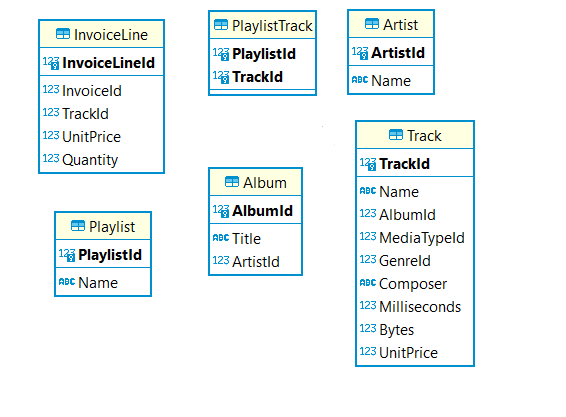

Exemple:

`Table1` --- `Table2`. Clé primaire: `Table2[nom_champ]` Clé étrangère: `Table1[nom_champ]`

**Réponse :**

*Album - Artist : Clé primaire : Artist.ArtistId / Clé étrangère : Album.ArtistId / Relation : Un artiste peut avoir plusieurs albums.*

*Track - Album : Clé primaire : Album.AlbumId / Clé étrangère : Track.AlbumId / Relation : Un album peut contenir plusieurs morceaux (tracks).*

*InvoiceLine - Track : Clé primaire : Track.TrackId / Clé étrangère : InvoiceLine.TrackId / Relation : Un morceau peut apparaître dans plusieurs factures.*

*PlaylistTrack - Track : Clé primaire : Track.TrackId / Clé étrangère : PlaylistTrack.TrackId / Relation : Un morceau peut appartenir à plusieurs playlists.*

*PlaylistTrack - Playlist : Clé primaire : Playlist.PlaylistId / Clé étrangère : PlaylistTrack.PlaylistId / Relation : Une playlist peut contenir plusieurs morceaux.*

> 2. **Compétence C1.3** Toujours en se basant sur le schéma de la base de données, existe-t-il une table intermédiaire ? Si oui, quel est le nom de cette table ? Dans quelle situation il est recommandé de créer une table intermédiare pour connecter deux tables ?



**Réponse:**

*Oui, il existe une table intermédiaire dans ce shéma de base de données.
Il s'agit de la table : PlaylistTrack car elle sert à relier les tables Playlist et Track.*

*Grâce à cette table, on crée une table intermédiaire comme PlaylistTrack lorsqu’un morceau peut appartenir à plusieurs playlists et qu’une playlist peut contenir plusieurs morceaux.*

*Il s'agit d'une relation plusieurs-à-plusieurs.*

3. Requêtes SQL

Exécuter la cellule de code ci-dessous pour se connecter à la base de données.

In [1]:
import requests
import zipfile
import sqlite3
import pandas as pd

# Here we download the file from GitHub
r = requests.get("https://github.com/WildCodeSchool/wilddata/blob/main/music.zip?raw=true")
open('music.zip', 'wb').write(r.content)

# Then we unzip it
with zipfile.ZipFile("music.zip","r") as zip_ref:
    zip_ref.extractall()

# We connect to the database
conn = sqlite3.connect('music.sqlite')



In [2]:
# Voici un exemple de requête sql. La requête SQL est entre guillemets pour le premier argument, puis la variable conn en second argument.

pd.read_sql("select * from album", conn)

,AlbumId,Title,ArtistId
0,1,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2
2,3,Restless and Wild,2
3,4,Let There Be Rock,1
4,5,Big Ones,3
...,...,...,...
342,343,Respighi:Pines of Rome,226
343,344,Schubert: The Late String Quartets & String Qu...,272
344,345,Monteverdi: L'Orfeo,273
345,346,Mozart: Chamber Music,274


Effectuer des requêtes, pour répondre aux questions suivantes.

> 3.1 **Compétence C1.4** Renvoyer le nom de la playlist qui contient le plus de morceaux, ainsi que le nombre de morceaux pour cette playlist.

Résultat attendu:

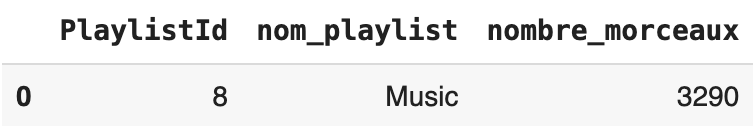

In [3]:
query = """
SELECT p.PlaylistId,
       p.Name AS nom_playlist,
       COUNT(pt.TrackId) AS nombre_morceaux
FROM Playlist AS p
JOIN PlaylistTrack AS pt
  ON p.PlaylistId = pt.PlaylistId
GROUP BY p.PlaylistId, p.Name
ORDER BY nombre_morceaux DESC, p.PlaylistId DESC
LIMIT 1;
"""

# Ligne 2 : Cette fonction permet de sélectionner le nom de la playlist en utilisant l'alias "nom_playlist".
# Ligne 3 : Cette fonction permet de compter le nombre de morceaux dans chaque playlist en utilisant l'alias "nombre_morceaux".
# Ligne 4 : Je sélectionne les données de la table Playlist en utilisant l'alias "p".
# Ligne 5 : J'effectue une jointure entre la table Playlist et la table Playlist
# Ligne 6 : Je groupe les résultats par PlaylistId et Name pour obtenir le nombre de morceaux par playlist.
# Ligne 7 : Je trie les résultats par nombre de morceaux en ordre décroissant.
# Ligne 8 : Je limite les résultats à la playlist avec le plus grand nombre de morceaux, avec une limite de 1.

result = pd.read_sql(query, conn)
print(result)

   PlaylistId nom_playlist  nombre_morceaux
0           8        Music             3290


> 3.2 Renvoyer les noms d'artistes, leur nombre de morceaux et leur nombre d'albums par artiste, dans l'ordre décroissant par rapport au nombre de morceaux.

Résultat attendu:

 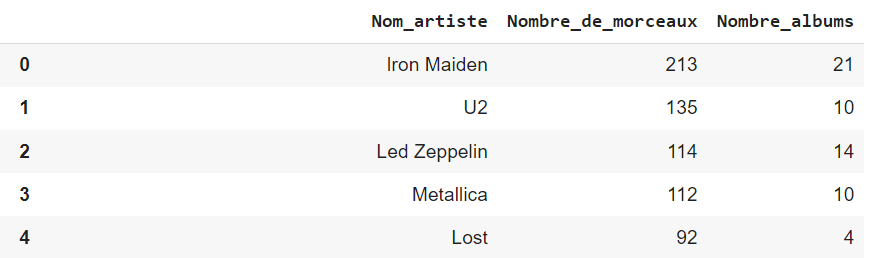

In [4]:
query = """
SELECT ar.Name AS Nom_artiste,              
       COUNT(DISTINCT al.AlbumId) AS Nombre_albums,       
       COUNT(t.TrackId) AS Nombre_de_morceaux             
FROM Artist AS ar
LEFT JOIN Album AS al ON ar.ArtistId = al.ArtistId        
LEFT JOIN Track AS t ON al.AlbumId = t.AlbumId            
GROUP BY ar.ArtistId, ar.Name                            
ORDER BY Nombre_de_morceaux DESC                          
"""

# Ligne 2 : Je sélectionne le nom de l'artiste et l'alias "Nom_artiste".
# Ligne 3 : Je compte le nombre d'albums distincts de l'artiste et l'alias "Nombre_albums".
# Ligne 4 : Je compte égaleme,t le nombre de morceaux de l'artiste et l'alias "Nombre_de_morceaux".
# Ligne 5 : Ensuite je sélectionne les données de la table Artist en utilisant l'alias "ar".
# Ligne 6 : J'effectue une jointure gauche entre la table Artist et la table Album                  
# Ligne 7 : Puis une jointure gauche entre la table Album et la table Track.
# Ligne 8 : Et je groupe les résultats par ArtistId et Name pour obtenir le nombre d'albums et de morceaux par artiste.
# Ligne 9 : Pour finir je trie les résultats par nombre de morceaux en ordre décroissant.  

result = pd.read_sql(query, conn)


print(result.head())

    Nom_artiste  Nombre_albums  Nombre_de_morceaux
0   Iron Maiden             21                 213
1            U2             10                 135
2  Led Zeppelin             14                 114
3     Metallica             10                 112
4   Deep Purple             11                  92


> 3.3 **Compétence C1.1** Créer une requête qui renvoie le nombre de morceaux distinct dans la table `Track`. On souhaite renvoyer le nombre de morceaux qui ont des noms différents.

Résultat attendu:

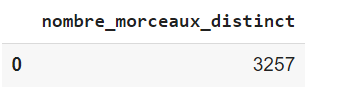

In [5]:
query = "SELECT COUNT(DISTINCT Name) AS nombre_morceaux_distincts FROM Track;"
result = pd.read_sql(query, conn)
print(result)

   nombre_morceaux_distincts
0                       3257


> 3.4. **Compétence C1.2** La maison de disque souhaiterai investir dans les genres qui sont les plus représentés, car ce sont les mieux vendu. Combien de morceaux contient le genre le plus représenté ?

Résultat attendu :

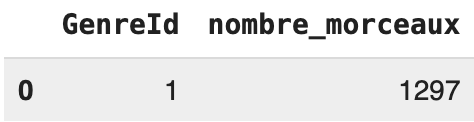

In [6]:
query = """
SELECT GenreId,                            
       COUNT(*) AS nombre_morceaux          
FROM Track
GROUP BY GenreId                          
ORDER BY nombre_morceaux DESC               
LIMIT 1;                                   
"""

# Ligne 2 : Je sélectionne l'ID du genre et l'alias "GenreId".
# Ligne 3 : Je compte le nombre de morceaux pour chaque genre et l'alias "nombre_morceaux".
# Ligne 4 : Je sélectionne les données de la table Track.             
# Ligne 5 : Je regroupe les résultats par GenreId pour obtenir le nombre de morceaux par genre.
# Ligne 6 : Je trie les résultats par nombre de morceaux en ordre décroissant.      
# Ligne 7 : Je limite les résultats au genre avec le plus grand nombre de morceaux, avec une limite de 1.


result = pd.read_sql(query, conn)
print(result)

   GenreId  nombre_morceaux
0        1             1297


---

## RGPD  



4: **Compétence C1.7** Que signifie RGPD, et quel est son objectif principal ?


**Réponse:**

*RGPD signifie : Règlement Général sur la Protection des Données. Il s'agit d'un règlement européen qui existe de le 25 mai 2018.
Son objectif est donc de renforcer la protection des données personnelles des cityoens de l'UE.*

---

## Web Scraping



5. **Compétence C1.5** Votre collègue de bureau à qui vous avez partagé le DataFrame `df_all` souhaite récuperer un descriptif de texte pour chaque arrondissement. C'est sa mission, pas la vôtre, donc vous allez vous contenter de répondre à sa question.
Votre collègue aimerait savoir si sa requête lui a permis d'avoir du contenu en retour.
Dans un cas, le code `response` lui renvoie "<Response [200]>", et dans l'autre cas, le code `response` lui renvoie "<Response [404]>".
Il ne comprend pas, et aimerait que vous lui expliquer ce que signifie chacune des deux réponses.
Soyez le plus clair possible, et écrivez votre réponse comme vous l'auriez expliqué à l'oral.

**Réponse:**

*Lorsqu'une requête retourne "<Response [200]>", cela signifie que tout s'est bien passé. Le serveur a bien compris la demande, et a donc a bien renvoyé le contenu demandé.*

*Par contre si la requête retourne "<Response [404]>", cela signifie qu'il n'a rien trouvé (Not Found), et donc n'affiche pas de contenu.*

*Pour éviter les erreurs 404, l'une des premières choses à faire est de vérifier si les noms des arrondissements sont bien nettoyés (espaces, majuscules, accents).*

---


## API

Voici les données de géolocalisation d'un appartement. L'objectif est de retrouver l'adresse de cet appartement à partir des coordonnées de géolocalisation ("latitude", "longitude"), grâce à une API.

In [7]:
latitude_appartement = 48.895622
longitude_appartement = 2.337501

6. **Compétence C1.6** Utiliser la partie **reverse** de l'API [`https://adresse.data.gouv.fr/api-doc/adresse`](https://adresse.data.gouv.fr/api-doc/adresse) pour récupérer l' adresse de l'appartement, en utilisant les variables "latitude_appartement" et "longitude_appartement".


In [8]:
# J'utilise l'URL de l'API de géocodage inverse du service adresse.data.gouv.fr
url = "https://api-adresse.data.gouv.fr/reverse"


# J'utilise un dictionnaire pour les paramètres de la requête : latitude et longitude pour plus de clarté.
params = {
    'lat': latitude_appartement,
    'lon': longitude_appartement
}

# J'envoi la requête GET à l'API avec les paramètres
response = requests.get(url, params=params)


# Et je vérifie si la requête s'est bien passée (je reprends le code d'état HTTP)
# Si le code d'état est 200, cela signifie que la requête a réussi.
if response.status_code == 200:
    data = response.json()
# Je fais une conversion de la réponse JSON en dictionnaire Python  afin d'avoir des données exploitables.
    


    # Je vérifie si l'API a trouvé une ou plusieurs adresses avec if/else
    if data['features']:
        # Récupère l'adresse lisible dans le premier résultat
        adresse = data['features'][0]['properties']['label']
        print("L'adresse est :", adresse)
    else:
        print("Aucune adresse trouvée pour ces coordonnées.")
else:
    # Affiche le code d'erreur HTTP 404 si la requête a échoué
    print("Erreur HTTP :", response.status_code)

L'adresse est : 111 Rue Damrémont 75018 Paris


---

# Pandas _(2 heures)_

Voici un Dataset `df_transactions` qui regroupe des transactions immobilières de la ville de Paris, entre 2018 et 2019.
L'objectif de ce cas pratique est de répondre à plusieurs questions.

In [9]:
import pandas as pd

df_transactions = pd.read_csv("https://raw.githubusercontent.com/WildCodeSchool/wilddata/main/transactions_paris.csv")

df_transactions

,id_mutation,valeur_fonciere,surface_reelle_bati,prix_m2,nombre_pieces_principales,type_local,nom_commune,nom_iris,code_commune,code_departement,code_iris,id_parcelles,longitude,latitude,date_mutation
0,2019-1064422,156000.0,19,8210,1,appartement,Paris 3e Arrondissement,Enfants Rouges 3,75103,75,751031003,75103000AK0097,2.361791,48.861877,2019-07-03
1,2019-1080094,495000.0,53,9339,3,appartement,Paris 15e Arrondissement,Saint-Lambert 10,75115,75,751155710,75115000BJ0016,2.283552,48.836610,2019-04-30
2,2019-1078635,430000.0,49,8775,3,appartement,Paris 15e Arrondissement,Saint-Lambert 24,75115,75,751155724,75115000BT0039,2.298475,48.841206,2019-01-17
3,2019-1069949,216000.0,30,7200,3,appartement,Paris 10e Arrondissement,Hopital Saint-Louis 3,75110,75,751104003,75110000BJ0070,2.371124,48.872010,2019-04-17
4,2019-1093709,500000.0,45,11111,2,appartement,Paris 18e Arrondissement,Grandes Carrieres 12,75118,75,751186912,75118000AV0086,2.338148,48.890540,2019-07-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,2019-1090117,206450.0,21,9830,1,appartement,Paris 17e Arrondissement,Epinettes 7,75117,75,751176807,75117000DH0132,2.321425,48.892270,2019-10-07
286,2018-1400990,113000.0,11,10272,1,appartement,Paris 18e Arrondissement,Clignancourt 24,75118,75,751187024,75118000BE0079,2.343846,48.895130,2018-05-23
287,2018-1391042,315000.0,30,10500,2,appartement,Paris 15e Arrondissement,Saint-Lambert 10,75115,75,751155710,75115000BK0018,2.288922,48.838097,2018-12-27
288,2018-1402082,366000.0,58,6310,4,appartement,Paris 18e Arrondissement,Chapelle 5,75118,75,751187205,75118000CZ0021,2.361734,48.893486,2018-07-26


> 7. **Compétence C2.6** Supprimer les valeurs aberrantes, qui ont une surface supérieure à 6000 et les insérer dans un DataFrame, nommé `df_outliers`. Renvoyer le nombre de lignes pour ce DataFrame.

In [10]:
# Pour commencer je créé le DataFrame des valeurs aberrantes avec df_outlisers et je vérifie avec surface_reelle_bati si la surface est supérieure à 6000
df_outliers = df_transactions[df_transactions['surface_reelle_bati'] > 6000]

# Enfin, j'affiche le nombre de lignes du DataFrame des valeurs aberrantes
print(f"Il y a {len(df_outliers)} lignes aberrantes pour ce DataFrame.")

Il y a 4 lignes aberrantes pour ce DataFrame.


> 8. **Compétence C2.6 (deuxième chance)** Vérifier le nombre de valeurs manquantes pour chaque colonne.

In [11]:
# Pour cela j'utilise la méthode isna() pour vérifier les valeurs manquantes dans chaque colonne du DataFrame df_transactions.
print(df_transactions.isna().sum())

id_mutation                  0
valeur_fonciere              0
surface_reelle_bati          0
prix_m2                      0
nombre_pieces_principales    0
type_local                   0
nom_commune                  0
nom_iris                     0
code_commune                 0
code_departement             0
code_iris                    0
id_parcelles                 0
longitude                    0
latitude                     0
date_mutation                0
dtype: int64


> 9. **Compétence C2.5** Observer le nombre de valeurs distinctes pour la colonne "type_local" pour `df_transactions`.

In [12]:
# Pour cet affichage, j'utilise la méthode nunique() pour compter le nombre de valeurs distinctes dans la colonne 'type_local'.
print(f"Il y a {df_transactions['type_local'].nunique()} valeur distincte dans 'type_local'.")

Il y a 2 valeur distincte dans 'type_local'.


> 10. **Compétence C2.5** Quelle est la moyenne de la "surface_reelle_bati" pour chaque valeur de la variable "type_local"?

In [13]:
# Pour calculer la moyenne de la surface réelle bâtie par type de local, j'utilise groupby et mean avec le nom de variable "moyennes".
# Je groupe les données par 'type_local' et je calcule la moyenne de 'surface_reelle_bati'. 
moyennes = df_transactions.groupby("type_local")["surface_reelle_bati"].mean()
print(moyennes)

type_local
appartement           47.356643
local industriel    8672.500000
Name: surface_reelle_bati, dtype: float64


---

## Regex

> 11. **Compétence C2.7, Compétence C2.3** Utiliser la librairie `re` (Regular Expression) pour extraire le code postal de l'adresse ci-dessous, à l'aide d'une fonction que vous allez créer:

In [14]:
adresse = "8 Passage Petit Cerf 75017 Paris"


In [15]:
# J'importe la librairie 're' pour les expressions régulières
import re

# Je définis une fonction pour extraire le code postal d'une adresse
# Avec re, j'utilise le motif \b\d{5}\b pour trouver un code postal de 5 chiffres
# Le  r, signifie une chaîne brute qui indique de ne pas interpréter les caractères spéciaux comme "\"
# Le \d, représente un chiffre (0 à 9)                                                    
# Le {5}, signifie que je cherche exactement 5 chiffres consécutifs                     
# Le \b, permet de capter uniquement les codes postaux de 5 chiffres, en évitant les chiffres supplémentaires avant ou après

def extraire_code_postal(adresse):
    match = re.search(r"\b\d{5}\b", adresse)                             
    if match:
        return match.group()
    else:
        return None

# Je réutilise la fonction pour extraire le code postal de l'adresse donnée
# Je passe l''adresse' en argument de la fonction
# Cette fonction utilise une expression régulière pour trouver un code postal de 5 chiffres
adresse = "8 Passage Petit Cerf 75017 Paris"
code_postal = extraire_code_postal(adresse)
print(f"Code postal extrait : {code_postal}")


Code postal extrait : 75017


## Méthode Agile SCRUM



> 12. **Compétence C2.2** Dans le cadre de l'utilisation de la méthode agile SCRUM, quelle est la différence entre le scrum master et le product owner ?

**Réponse :**

*Le Product Owner est un décideur qui définit les priorités. C'est lui qui rencontre les clients, note leurs besoins et tranforme le tout en tâches à exécuter pour l'équipe (appelé user stories). Ces tâches sont dans une liste appelée "backlog".*

*Le Scrum Master, quant à lui est un "coach" pour l'équipe en s'appuyant sur la méthode "Scrum" qui est une méthode de travail, dite "agile". Cette méthode repose des cycles courts appelés sprints (en général 2 semaines), et une amélioration continue du produit et de la façon de travailler.*



---

## Sélection de données

Voici un nouveau Dataset `df_transactions` qui regroupe des transactions immobilières de la ville de Paris, entre 2018 et 2019.



In [16]:
import pandas as pd

df_transactions = pd.read_csv("https://raw.githubusercontent.com/WildCodeSchool/wilddata/main/transactions_immobilieres_75.csv")

df_transactions.head(1)

,id_mutation,valeur_fonciere,surface_reelle_bati,prix_m2,nombre_pieces_principales,type_local,nom_commune,nom_iris,code_commune,code_departement,code_iris,id_parcelles,longitude,latitude,date_mutation
0,2018-1404085,280000.0,25,11200,2,appartement,Paris 20e Arrondissement,Belleville 4,75120,75,751207704,75120000AL0064,2.389542,48.8723,2018-01-02


> 13.**Compétence C2.1** Créer un nouveau DataFrame `df_flats` qui ne regroupe que les appartements. Combien de lignes contient `df_flats` ?

In [17]:
# Je sélectionne uniquement les lignes où le bien est un appartement
df_flats = df_transactions[df_transactions["type_local"] == "appartement"]

# Je stocke dans la variable 'nombre_lignes_df_flats' le nombre de lignes (donc le nombre de transactions pour des appartements) 
nb_lignes_flats = df_flats.shape[0]
nb_lignes_flats

print("Nombre de lignes dans df_flats :", df_flats.shape[0])

Nombre de lignes dans df_flats : 48921


# Machine Learning _(4 heures)_

## Sélection de données et NLP *(30 minutes)*

Dans ce cas pratique Machine Learning,  notre objectif sera de créer un algorithme capable de prédire le prix d'appartements, pour la ville de Paris. Vous utiliserez donc le DataFrame `df_flats`.

> 13. Ne garder que les colonnes [`valeur_fonciere`, `surface_reelle_bati`, `nombre_pieces_principales`, `code_commune`] pour le DataFrame `df_flats`.

In [18]:
# Je sélectionne uniquement les colonnes utiles pour l'analyse
# Je définis une liste de colonnes utiles
# Et pour finir, je copie le DataFrame df_flats pour ne pas modifier l'original
colonnes = ["valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales", "code_commune"]

> **Compétence C3.5** 14. On aimerait enrichir notre jeu de données avec une variable qui contient du texte pour chaque ligne. Citez un nom de variable explicite, qui permettrait d'enrichir notre jeu de données. En quoi cette variable de texte constituerait une valeur ajoutée pour le jeu de données `df_flats`.  Si vous pourriez créer cette colonne, comment est-ce que vous procéderiez techniquement pour l'exploiter ? Est-ce que cette variable de texte pourrait avoir un impact conséquent sur les performances d'un modèle de prédiction ? Si oui, pourquoi ?



**Réponse**

*Je peux ajouter une nouvelle colonne "description_bien" qui contient une phrase décrivant chaque appartement (comme dans une annonce).*

*Cette colonne texte peut rajouter que les chiffres ne fournissent pas, comme : "balcon", "rénové", "vue dégagée", etc.*

*Pour l’utiliser, je dois transformer le texte en nombres avec un outil comme CountVectorizer, qui compte combien de fois chaque mot apparaît.*

*Ça peut aider à mieux prédire le prix si les descriptions sont claires et contiennent des mots importants.*

*Mais si les phrases sont trop vagues ou répétitives, ça peut embrouiller le modèle.*

*En résumer, tout dépend des descriptions si elles sont bien écrites et précises.*

### Partie Machine Learning - Regression _(1 heure 45 minutes)_

> 14. Créer `X` et `y` en vue d'entraîner un modèle capable de prédire le prix d'appartements.
`X` est composé des variables `surface_reelle_bati`, `nombre_pieces_principales` et `code_commune`.
`y` est la variable `valeur_fonciere`.


In [19]:
# Étape 1 — Sélection des variables utiles et nettoyage
df_flats_clean = df_flats[["surface_reelle_bati", "nombre_pieces_principales", "code_commune", "valeur_fonciere"]].dropna()

# Étape 2 — Définir X et y
X = df_flats_clean[["surface_reelle_bati", "nombre_pieces_principales", "code_commune"]]
y = df_flats_clean["valeur_fonciere"]

# Vérification rapide
print("X :", X.shape)
print("y :", y.shape)


X : (48921, 3)
y : (48921,)


> 15. La colonne `code_commune` contient des codes, représentant les arrondissements, ce qui signifie que ce sont des valeurs discrètes. Il est donc nécessaire de créer autant de colonnes qu'il y a de valeurs distinctes pour cette colonne. Aussi, il faudra supprimer la colonne `code_commune` pour ne garder que les colonnes qui ont été générées à partir de cette dernière.

In [20]:
# Je transforme la variable catégorielle 'code_commune' en variables numériques avec pd.get_dummies
# J'utilise pd.get_dummies pour créer des variables indicatrices pour chaque code_commune
# Je supprime la colonne originale 'code_commune' en utilisant drop_first=True pour éviter la multicolinéarité (lorsque plusieurs variables indépendantes d’une équation de régression linéaire sont corrélées entre elles)
# Je stocke le résultat dans X_encoded, car les codes numériques bruts pourraient induire le modèle en erreur
X_encoded = pd.get_dummies(X, columns=["code_commune"], drop_first=True)

> 16. **Compétence C3.2** Séparer les données en jeu d'entraînement et jeu de test, avec `random_state = 0`

In [21]:
from sklearn.model_selection import train_test_split

# Supposons que X contient les caractéristiques et y les étiquettes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)   

> 17. Importer le modèle `Linear Regression` de la librairie `sklearn`

In [22]:
from sklearn.linear_model import LinearRegression

> 18. **Compétence C3.3** Entraîner le modèle sur le jeu d'entraînement, puis évaluer les performances du modèle sur le jeu de test. A l'écrit, interpréter le score obtenu, et donner le nom de la métrique utilisé pour évaluer le score du modèle.

In [23]:
# J'utilise la régression linéaire pour entraîner le modèle avec les données d'entraînement vues plus haut
model = LinearRegression()
model.fit(X_train, y_train)

# J'évalue le modèle sur le jeu de test
# La méthode .score() renvoie ici le coefficient de détermination R²,
# qui mesure la proportion de la variance de y expliquée par X
score = model.score(X_test, y_test)

# J'affiche le score R²
# R² varie entre -∞ et 1.0 : plus il est proche de 1, meilleure est la qualité du modèle
print("Score R² du modèle :", score)


Score R² du modèle : 0.8404628190183383


**Réponse:**

*Le modèle de régression linéaire a obtenu un score R² de 0.84 sur le jeu de test.*

*Cela signifie que 84 % de la variance du prix des appartements (valeur_fonciere) est expliquée par les variables utilisées précédements.*

*Ici, le modèle capte bien la structure des données, donc les variables sélectionnées sont pertinentes pour expliquer le prix des biens immobiliers.*

> 19. **Compétence C3.7** Expliquer et vulgariser le fonctionnement interne de l'algorithme, pour qu'il puisse faire ses prédictions.
Expliquer aussi quelles sont la, ou le(s) variable(s) utilisé par l'algorithme pour faire ses prédictions de prix.

**Réponse :**

*Le fonctionnement interne de l'algorithme est comme un calculateur intelligent, cependant il faut le guider avec un certains nombre d'informations. *

*Dans le cas ici, si je lui donne une surface en m², un nombre de pièces et son emplacement (Paris), il pourra me faire une extimation prix si je souhaite acheter un appartement à Paris.*

> 20. **Compétence C3.1** Afficher la matrice de corrélation pour `df_flats`. Quelles sont les deux variables qui ont la corrélation la plus élevée avec `y`, c'est à dire "valeur foncière" ?

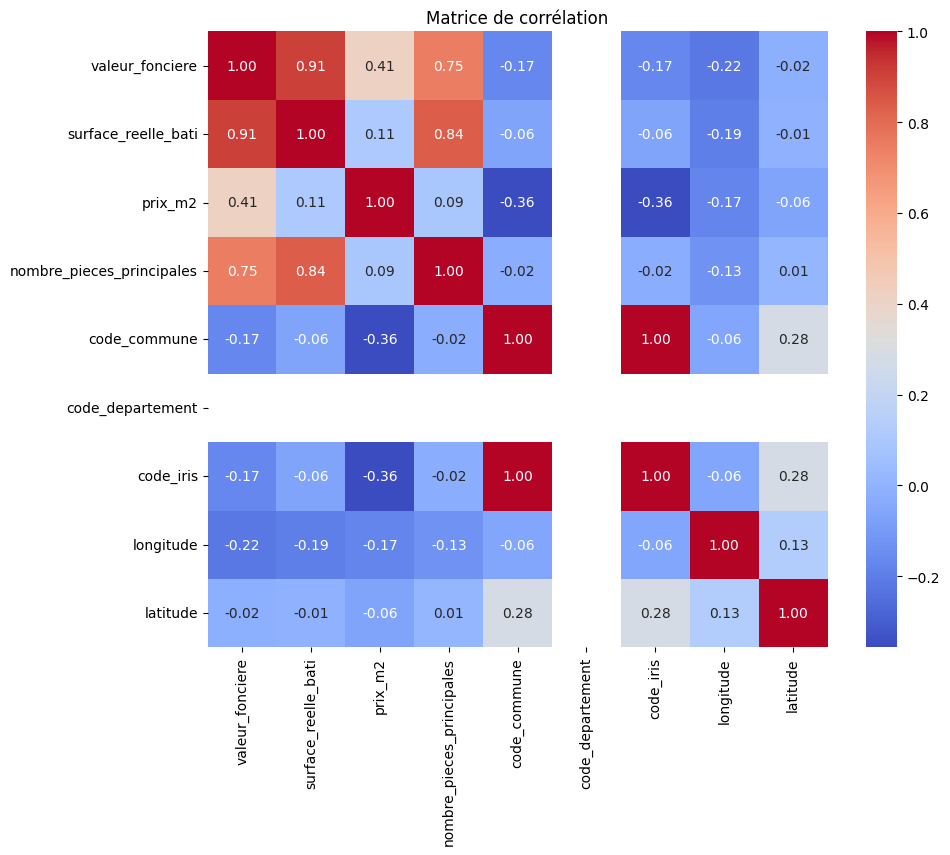

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Je sélectionne uniquement les colonnes numériques
corr_matrix = df_flats.select_dtypes(include="number").corr()

# J'affichage de la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

**Réponse :**

*Le premier constat est par rapport aux couleurs :
Rouge = Corrélation positive forte
Bleu = Corrélation négative fort
Blanc = Corrélation proche de zéro (donc pas de lien à faire)*

*Il y a deux variables en fort corrélation avec "valeur_fonciere" :
1 - surface_reelle_bati = corrélation = 0.91, donc plus c’est grand, plus c’est cher.
2 - nombre_pieces_principales = corrélation = 0.75, donc plus il y a de pièces, plus le prix tend à augmenter.*

*La corrélation de 0.91 avec la surface est très forte, ce qui veut dire que la taille du bien est un facteur déterminant du prix.
La corrélation de 0.75 avec le nombre de pièces montre également une influence significative sur le prix d'achat.*

### Partie Machine Learning - Classification _(1 heure 45 minutes)_



In [25]:
df_ml_idf = pd.read_csv("https://raw.githubusercontent.com/WildCodeSchool/wilddata/main/transactions_idf_no_paris.csv")
df_ml_idf.head(1)

,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,type_local
0,282000.0,101,4,maison


> 21. Créer `X` et `y` en vue d'entraîner un modèle capable de prédire si un logement est une maison ou un appartement.
`X` est composé des `valeur_fonciere`, `surface_reelle_bati` et`nombre_pieces_principales`.
`y` est la variable `type_local`.

In [26]:
# Je commence par supprimer des lignes avec des valeurs manquantes dans les colonnes utiles
df_ml_idf_clean = df_ml_idf.dropna(subset=["valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales", "type_local"])

# Je reprend l'énoncé pour la création de X (features) et de y (target)
X = df_ml_idf_clean[["valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales"]]
y = df_ml_idf_clean["type_local"]


> 22. Séparer les données en jeu d'entraînement et jeu de test, avec random_state = 0

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

> 23. Importer le modèle `DecisionTreeClassifier` ou `KNeighborsClassifier` de la librairie sklearn.

In [28]:
# Je décide d'utiliser un arbre de décision pour la classification car il est simple à interpréter et efficace pour les données catégorielles.
from sklearn.tree import DecisionTreeClassifier

> 24. **Compétence C3.4** Entraîner le modèle sur le jeu d'entraînement, puis évaluer les performances du modèle sur le jeu de test. A l'écrit, interpréter le score obtenu, et donner le nom de la métrique utilisé pour évaluer le score du modèle.

In [29]:
from sklearn.metrics import accuracy_score

# Pour commencer, je crée une instance du classificateur d'arbre de décision
# Je fixe un random_state pour assurer la reproductibilité des résultats
model = DecisionTreeClassifier(random_state=0)

# Ensuite, j'entraîne le modèle sur les données d'entraînement
# La méthode .fit() ajuste le modèle aux données d'entraînement
model.fit(X_train, y_train)

# Je prédis les classes sur les données de test
y_pred = model.predict(X_test)

# J'évalue le modèle sur les données de test 
# La fonction accuracy_score calcule la proportion de prédictions correctes
accuracy = accuracy_score(y_test, y_pred)

# Enfin, j'affiche le score
print("Accuracy du modèle sur le jeu de test :", accuracy)

Accuracy du modèle sur le jeu de test : 0.7812122504085838


**Réponse :**

> 25. **Compétence C3.6** On exploite ici des données pour le jeu d'entraînement, et des données pour le jeu de test. Quelles sont les limites de cette méthode ?

**Réponse :**

*Les limites de cette méthode pour le jeu d'entrainement précédent sont :*

*1 - Un résultat peu représentatif : le score obtenu avec accuracy_score(y_test, y_pred) dépend d’un seul découpage (avec train_test_split).
Si on change random_state, le score peut varier.*

*2 - Aucun mesure de stabilité sud modèle : en testant le modèle qu’une seule fois, on ne sait pas s’il est robuste à différents échantillons de données.*

*3 - Une utilisation partielle des données : le modèle n’est entraîné que sur 75 % des données (X_train), donc il n’exploite pas tout le dataset.*

*4 - Il y a un risque "d'optimiser " sur le jeu de text : en effet si on ajuste plusieurs fois les paramètres en se basant sur X_test, on finit par adapter le modèle à ces données, ce qui fausse l’évaluation.*

*De mon point de vue, pour améliorer le jeu d'entrainementn il faudrait répéter l’entraînement et le test plusieurs fois sur des découpages différents (ce qu'on appelle une validation croisée). Lorsque l'on entraîne une seule fois, le score peut être trop optimiste ou trop pessimiste, simplement à cause du hasard du découpage.*

*En répétant l’évaluation sur plusieurs portions différentes des données, on obtient une moyenne plus représentative de la vraie performance du modèle.*

> 26. Afficher la matrice de confusion (`confusion matrix`) et la commenter. Expliquer les métriques `precision` et `recall`.

**Réponse :**

*La métrique 'precision', (précision) permet de déterminer si le modèle se trompe souvent quand il affirme quelque chose.
Par exemple lorsqu'il déclare que ce logement est une maison, combien étaien vraiment des maisons ? 
Si le modèle dit souvent "maison" à tort, la précision est basse.
Par contre s’il dit “maison” uniquement quand il est sûr, la précision est haute.*


*La métrique 'recall', (rappel) permet de déterminer si le modèle oublie des cas importants.
Par exemple, a-t-il vraiment trouvé des maisons ?
Parmi toutes les vraies maisons, combien le modèle a-t-il réussi à identifier ?
S’il en rate beaucoup, le rappel est faible.
Par contre s’il en trouve une majorité, le rappel est bon.*

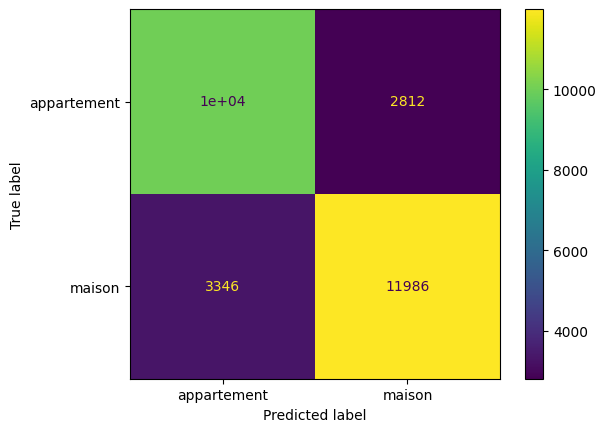

In [30]:
# Pour commencer je vais importer les bibliothèques nécessaires pour la matrice de confusion et les métriques de précision et de rappel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score

# J'effectue les prédictions 
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

# J'ai créé la matrice de confusion avec confusion_matrix via la variable cm
# J'ai affiché la matrice de confusion avec ConfusionMatrixDisplay
# Elle permet de visualiser les performances du modèle en termes de faux positifs, faux négatifs, vrais positifs et vrais négatifs
# True Label (étiquette réelle), c’est la vraie classe du logement dans le jeu de test.
# Predicted Label (étiquette prédite), c’est la classe que le modèle a prédit pour ce logement.
# Enfin, j'utilise la fonction ConfusionMatrixDisplay pour afficher la matrice de confusion

**Commentaire:**

*Le modèle identifie bien les maisons :
Il en trouve 11 986 sur 15 332, soit environ 78 % donc le est rappel correct.*

*Il est plutôt fiable quand il prédit "maison" :
Sur 15 332 prédictions "maison", 11 986 sont correctes, soit environ 78 % de précision correcte.*

*Cependant le modèle fait plus d’erreurs sur les maisons que sur les appartements :
Il rate 2 812 appartements, en les prenant pour des maisons.
Il confond 3 346 maisons avec des appartements.*

*En conclusion, le modèle est globalement précis et équilibré, malgré certaines disparités.
Il reconnaît bien les maisons dans 78 % des cas, et quand il prédit "maison", il a environ 78 % de chances d’avoir raison.*

# Étude de marché - Vin _(8 heures)_

Le client, le Domaine des Croix, cherche à se lancer sur le marché américain . Il souhaite donc **définir le prix** de ses bouteilles de vin **pour être compétitif sur le marché américain**. Il a récupéré un jeu de données de 130k bouteilles de vin, avec les cépages, les pays et région de production, les millésimes (c'est-à-dire les années de production), ainsi que des notes ("points") et descriptifs d'oenologues (les spécialistes du vin), et le prix moyen en dollars de toutes ces bouteilles sur le marché américain.

**L'objectif sera de faire une présentation de l'analyse du marché, et du prix que vous conseillez de fixer pour les vins du client.** Le client n'est pas data analyst, mais souhaiterait comprendre la démarche. Il faudra donc s'attacher à expliquer comment les prix ont été fixés, sans rentrer dans un trop grand niveau technique, autrement dit : vulgariser.




## Jeux de données
- Dataset des 130k vins : https://github.com/WildCodeSchool/wilddata/raw/main/wine.zip
- Dataset de la bouteille de vin que le client aimerait proposer sur le marché américain : https://raw.githubusercontent.com/WildCodeSchool/wilddata/main/domaine_des_croix.csv


## Livrables attendus
**Compétence C4.6, Compétence C4.1** Le client souhaite une présentation (et non pas du code)
La présentation contiendra a minima ces éléments :
- Rappel du contexte et de la problématique
- Analyse exploratoire des données
- Méthodologie, outils et langages utilisés  **Compétence C2.2**
- Présentation de la partie technique et du code créé, si code il y a, pour cette analyse
- Votre tableau de bord contient des graphiques. **Compétence C4.2**
- Votre tableau de bord contient au moins une visualisation de données interactive. **Compétence C4.3**
- Votre tableau de bord contient au moins une carte représentant des informations géographiques. **Compétence C4.4**
- Votre tableau de bord contient au moins un tableau croisé. **Compétence C4.5**
- L'ensemble des graphiques et visuels doivent être lisible par tous (prise en compte des personne en situation de handicap visuel). **Compétence C4.7**
- Réponse à la question métier : proposition de prix ou de fourchette de prix au client pour être correctement positionné face à la concurrence sur le marché américain

Effectuez tout d'abord la trame ci-dessous. Puis, si vous avez des bonnes idées à proposer au client, elles sont évidemment les bienvenues.



## Préparation des données et exploration des données

## Analyse du marché
Le Domaine des Croix souhaiterait une analyse descriptive du marché du vin. Vous allez donc réaliser un ensemble de dataviz, avec l'outil de votre choix (Seaborn, Plotly, Excel, PowerBI, Tableau, etc...). Vous pouvez par exemple intégrer dans votre tableau de bord:
- la répartition du nombre de vins par pays
- les pays qui ont les meilleures notes
- les moyennes de notes par cépage
- la répartition par décile
- etc...



## Analyse comparative

L'objectif ici sera de comparer chacun des vins du client par rapport à ses concurrents sur le marché. Par exemple, comparer les tarifs pratiqués pour les vins français, puis de plus en plus précisément, les vins de Bourgogne puisque notre client est en Bourgogne, puis les Pinot Noir bourguignons de la même année.
N'hésitez pas à être original dans la présentation et les dataviz utilisées.

## Proposition de valeur

Avec le tableau de bord que vous lui avez fourni, le client a une idée précise de ses concurrents. Faites lui une proposition de prix en fonction de sa volonté de positionnement (par exemple : "si vous souhaitez vous positionner sur le haut de gamme, les 25% les plus chers de vos concurrents sont à ce tarif, nous vous conseillons donc de vous aligner sur ce prix").

## Qualité esthétique du tableau de bord

Essayez de garder un oeil critique et visuel sur votre tableau de bord. La forme compte autant que le fond pour le client qui n'est pas data analyst. Pensez donc à "vendre" votre analyse. Par exemple, avec des couleurs s'inspirant du milieu vinicole, des dataviz originales, etc...

## C'est à vous de jouer:

In [31]:
link = "https://github.com/WildCodeSchool/wilddata/raw/main/wine.zip"
df = pd.read_csv(link)

df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2019 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,20.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2017 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,18.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2019 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,18.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2019 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2016, this...",Vintner's Reserve Wild Child Block,87,44.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2018 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [32]:
# Dans cette première étape, je vais créer un DataFrame df_clean en supprimant les lignes avec des valeurs manquantes dans les colonnes utiles
# Ensuite je vais supprimer les lignes sans pays, note ou cépage (variety)
# Je garde uniquement les points entre 80 et 100 (gamme qualitative normale)

initial_shape = df.shape
df_clean = df.dropna(subset=["country", "points", "variety"])
df_clean = df_clean[df_clean["points"].between(80, 100)]

# Aperçu après nettoyage
cleaned_shape = df_clean.shape
initial_shape, cleaned_shape

((129957, 13), (129893, 13))

**Commentaire:**

*Cette première partie m'a permis de supprimer 64 lignes incomplètes, et de garder 129 893 lignes.
En effet il y avait 129957 lignes au départ moins 64 lignes avec des valeurs manquantes, ce qui nous donne 129893 lignes.
Et enfin le tout repose sur 13 colonnes.*

**Analyse du marché :**

La répartition du nombre de vins par pays :

C:\Users\phili\AppData\Local\Temp\ipykernel_25824\3370296387.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="Oranges_r")


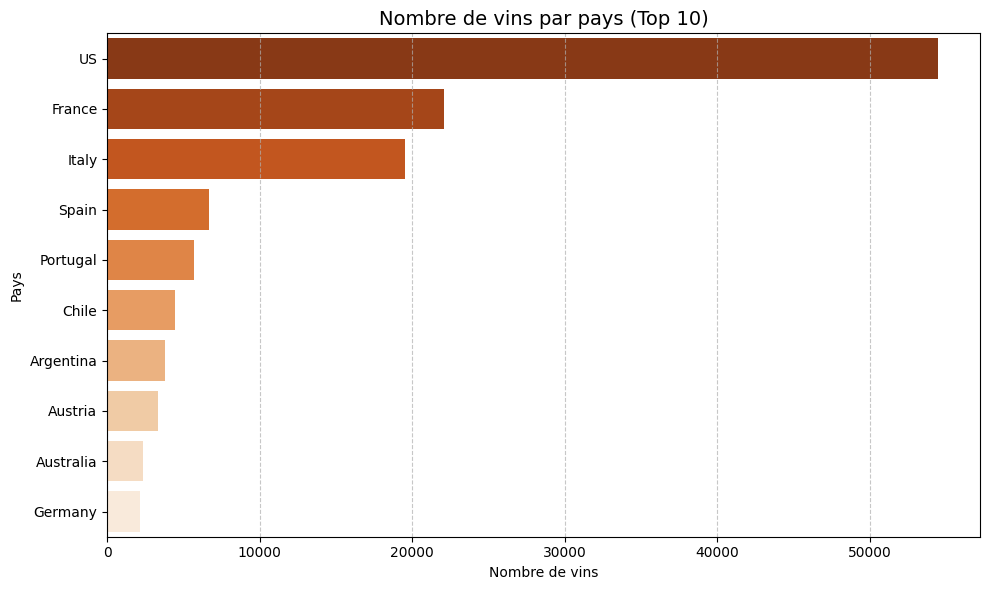

In [33]:
# J'importe les bibliothèques nécessaires pour la visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Étape 1 : Je compte le nombre de vins par pays
# value_counts() compte combien de fois chaque pays apparaît
# head(10) garde les 10 premiers pays les plus représentés
top_countries = df_clean["country"].value_counts().head(10)

# Étape 2 : Je créé une figure de taille 10x6 pouces
plt.figure(figsize=(10, 6))

# Étape 3 : Je créé un graphique en barres horizontales
# Avec les valeurs (nombre de vins) pour l'axe x
# Et les noms des pays pour l'axe y
sns.barplot(x=top_countries.values, y=top_countries.index, palette="Oranges_r")

# Étape 4 : Je rajoute un titre au graphique
plt.title("Nombre de vins par pays (Top 10)", fontsize=14)

# Étape 5 : Je créé des étiquettes aux axes
plt.xlabel("Nombre de vins")
plt.ylabel("Pays")

# Étape 6 : J'ajoute une grille sur l'axe des x pour mieux lire les valeurs
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Étape 7 : Je fais un ajustement sur l'affichage pour éviter que les textes se chevauchent
plt.tight_layout()

# Étape 8 : Le graphique
plt.show()


**Mon analyse de ce graphique :**

*Tout d'abord, je rappelle que ce graphique a été créé à l'aide du dataset fournis.
Il ne s'agit donc pas d'une analyse mondiale, ce qui explique que les États-Unis soient en tête de ce graphique.
En effet le top trois des pays producteurs de vin sont l'Italie, l'Espagne et la France sur le marché mondial.*

*Les observations que je peux faire sur ce graphique sont les suivantes :*

*Les États-Unis sont en premier avec plus de 50 000 vins. 
La France, en seconde position, avec plus de 20 000 vins.
L'Italie, en troisième position, avec un peu moins de 20 000 vins.*





Les pays qui ont les meilleures notes :

C:\Users\phili\AppData\Local\Temp\ipykernel_25824\3591814248.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries_by_score.values, y=top_countries_by_score.index, palette="Greens_r")


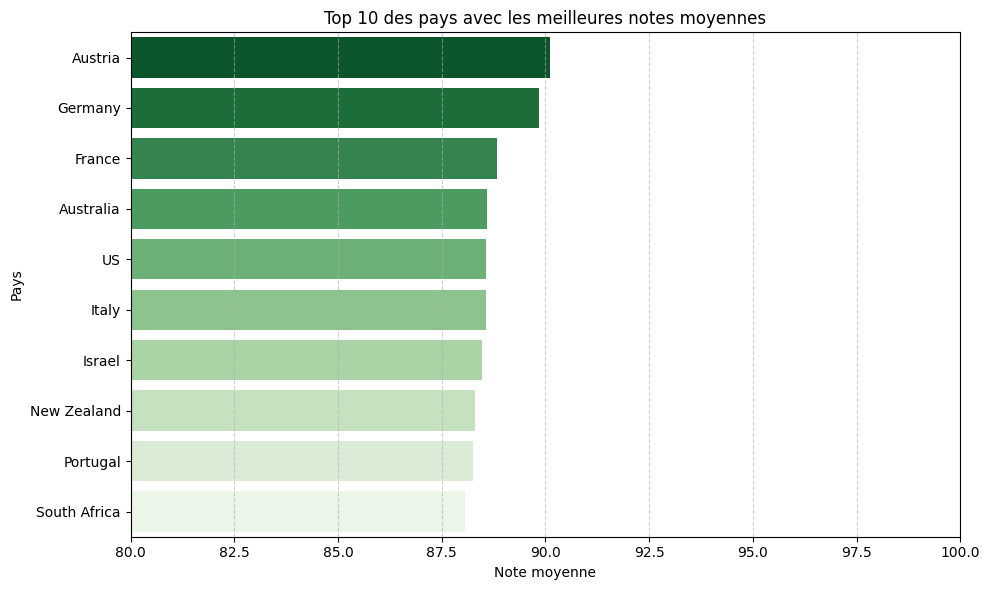

In [34]:
# Étape 1 : Je calcul de la moyenne des notes par pays (avec filtre sur pays sur plus de 500 vins)
country_counts = df_clean["country"].value_counts()
valid_countries = country_counts[country_counts >= 500].index
avg_points_by_country = df_clean[df_clean["country"].isin(valid_countries)].groupby("country")["points"].mean()
# isin est un filtre au dataframe pour ne garder que les lignes où le pays est bien dans valid_countries 

# Étape 2 : Trier les pays par note moyenne décroissante (Top 10)
top_countries_by_score = avg_points_by_country.sort_values(ascending=False).head(10)

# Étape 3 : Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries_by_score.values, y=top_countries_by_score.index, palette="Greens_r")
plt.title("Top 10 des pays avec les meilleures notes moyennes")
plt.xlabel("Note moyenne")
plt.ylabel("Pays")
plt.xlim(80, 100)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Mon analyse de ce graphique :**

*Tout d'abord,on peut constater que l'Autriche se démarque d'un manière significative avec une note moyenne de plus de 90.
Ensuite, on peut voir que l'Allemagne est juste en dessous avec une note moyenne de 89.
Puis, la France vient en troisième position avec une note moyenne de 88.*

Les moyennes de notes par cépage :

In [35]:
# Compter le nombre total de cépages uniques dans le dataset nettoyé
unique_varieties_count = df_clean["variety"].nunique()
unique_varieties_count

701

*Le résutat est de 701 cépages recensés dans le dataset.*

C:\Users\phili\AppData\Local\Temp\ipykernel_25824\3798003317.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


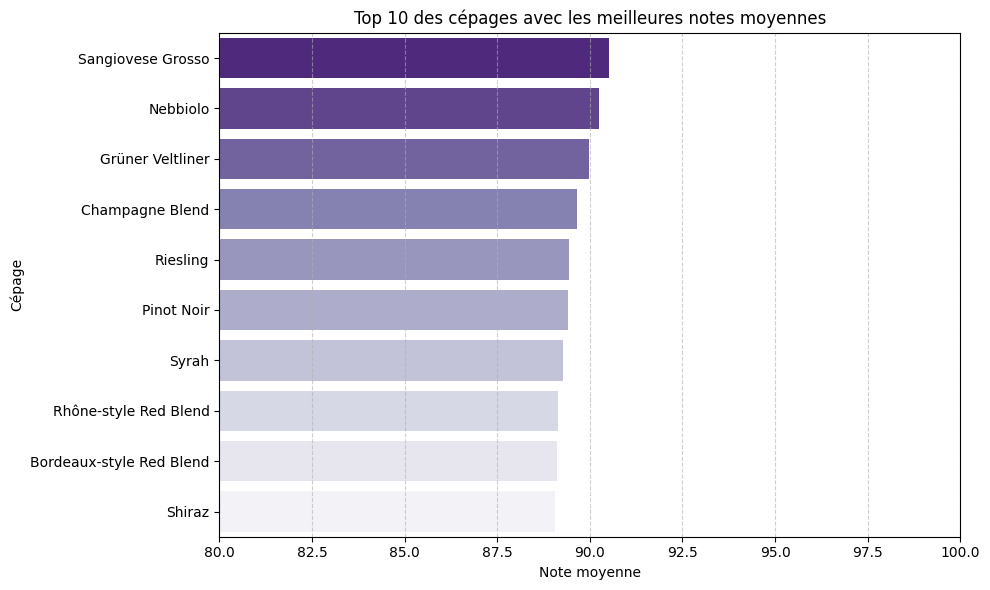

In [36]:
# Étape 1 : Je filtrer les cépages les plus représentés
# Je compte combien de fois chaque cépage apparaît
variety_counts = df_clean["variety"].value_counts()

# Je garde uniquement les cépages avec au moins 300 vins 
# Je reprends le nombre total de cépages valides
valid_varieties = variety_counts[variety_counts >= 701].index

# Étape 2 : Je calcule la moyenne des notes pour chaque cépage sélectionné
# Je garde uniquement les lignes avec les cépages valides
# Puis je groupe les lignes par cépage, et je calcule la moyenne des notes
avg_points_by_variety = (
    df_clean[df_clean["variety"].isin(valid_varieties)]
    .groupby("variety")["points"]
    .mean()
)

# Étape 3 : Je trier les cépages par note moyenne décroissante et je prend les 10 meilleurs
top_varieties_by_score = avg_points_by_variety.sort_values(ascending=False).head(10)

# Étape 4 : Je fais une visualisation avec un graphique en barres horizontales
plt.figure(figsize=(10, 6)) 

# J'utilise le Seaborn
sns.barplot(
    x=top_varieties_by_score.values,     
    y=top_varieties_by_score.index,       
    palette="Purples_r"                  
)

# Le graphique
plt.title("Top 10 des cépages avec les meilleures notes moyennes")
plt.xlabel("Note moyenne")
plt.ylabel("Cépage")
plt.xlim(80, 100)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Mon analyse de ce graphique :**

*Sangiovese Grosso est le cépage qui a la meilleure note moyenne, avec plus 91 points.
Ensuite, on trouve le cépage Nebbiolo avec une note moyenne de 90 points
Ensuite, on trouve le cépage Grüner Veltliner avec une note moyenne de 89 points.*

La répartition par décile :

*Rappelle de définition : Le décile est une mesure statistique qui divise un ensemble de données en dix parties égales. 
Chaque partie représente une tranche de 10% des données.*

C:\Users\phili\AppData\Local\Temp\ipykernel_25824\3877605422.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


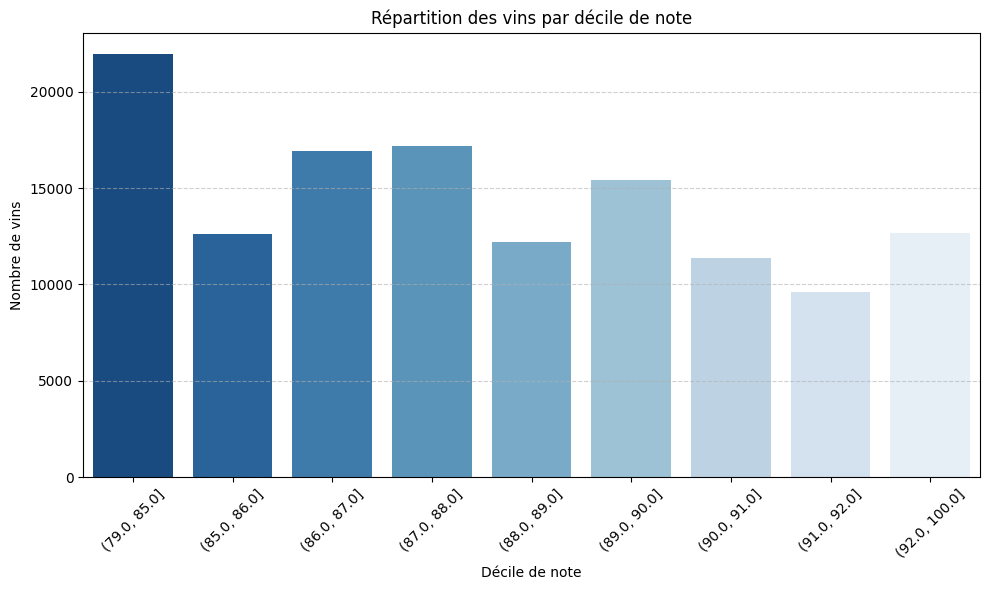

In [37]:
# Étape 1 : Je crée les déciles de note
# Je découpe la colonne "points" (notes) en 10 groupes
# La precision=0, permet un arrondit les bornes
# La duplicates="drop", permet d'éviter une erreur si certaines tranches sont identiques
deciles = pd.qcut(df_clean["points"], 10, precision=0, duplicates="drop")

# Étape 2 : Je compte combien de vins se trouvent dans chaque tranche (décile)
decile_counts = deciles.value_counts().sort_index()

# Étape 3 : Je crée la figure pour le graphique
plt.figure(figsize=(10, 6))

# Étape 4 : Je crée un graphique en barres verticales (à l'inverse des barres horizontales car je veux les déciles sur l'axe X)
# x = les tranches de notes
# y = le nombre de vins dans chaque tranche
sns.barplot(
    x=decile_counts.index.astype(str), 
    y=decile_counts.values,          
    palette="Blues_r"                  
)

# Étape 5 : J'ajoute le titre et les étiquettes aux axes
plt.title("Répartition des vins par décile de note")
plt.xlabel("Décile de note")
plt.ylabel("Nombre de vins")

# Étape 6 : J'effectue une rotation des étiquettes de l'axe X pour une meilleure lisibilité
plt.xticks(rotation=45)

# Étape 7 : Comme précédement, j'ajoute une grille horizontale pour faciliter la lecture
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Étape 8 : Je fais un ajustement automatiquement sur les marges pour éviter que ça coupe
plt.tight_layout()

# Étape 9 : Le graphique
plt.show()


**Mon analyse de ce graphique :**

*Tout d'abord,on peut constater que ce graphique présente bien les notes des vins, répartis en 10 déciles (donc par tranches de 10 %).
Chaque barre représente un nombre de vins appartenant à un intervalle de note.*

*La tranche de note de 79 à 85, qui correspond au premier décile, contient très peu de vins.
Celle de la tranche de note de 92 à 100 contient les vins les mieux notés, ce qui correspond au dernier décile.*

*On peut observer que la majorité des vins se situent entre 87 et 91 points, ce qui représente environ 60 % du datasat.
Très peu de vins sont notés de 80 à 85, ce qui montre un biais de qualité élevée dans les données.
Le dernier décile contient les vins les mieux notés (94 à 100), ce qui permet de situer comme vins haut de gamme.*

Distribution des prix des vins dans le dataset (moins de 200 $) :

*Dans cette partie, je vais analyser la répartition des prix des vins dans le dataset.
J'ai pris le Dollar comme monnaie car mon client, dont le marché cible est américain.
Cela permet de ne pas à refaire un autre graphique pour la conversion euro-dollar.*

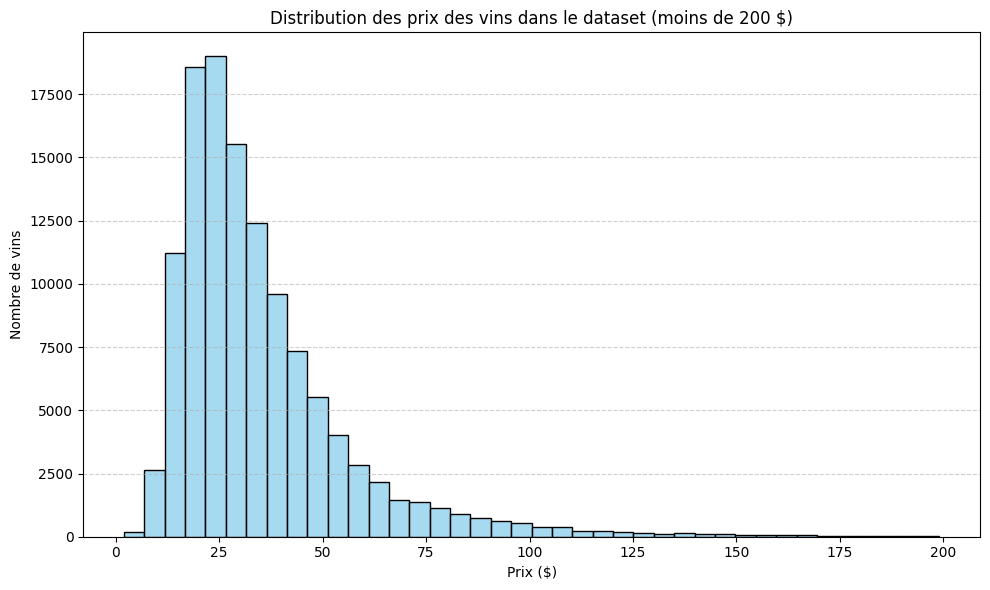

In [38]:
# Je créé un DataFrame df_price en filtrant les prix valides et raisonnables (moins de 200 $)
# Je prends 200 $ comme référence limite pour les prix des vins, sachant qu'à partir de 100 $ les vins sont considérés comme très haut de gamme et beaucoup moins nombreux.

df_price = df_clean[df_clean["price"].notnull() & (df_clean["price"] < 200)]


# Le graphique
plt.figure(figsize=(10, 6))
sns.histplot(df_price["price"], bins=40, kde=False, color="skyblue")
plt.title("Distribution des prix des vins dans le dataset (moins de 200 $)")
plt.xlabel("Prix ($)")
plt.ylabel("Nombre de vins")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Mon analyse de ce graphique :**

*On observe une forte concentration de vins entre 10 et 50 $, ce qui représente la gamme de prix la plus fréquente sur le marché.
C'est celle qui est la plus acheté par les consommateurs (de classe moyenne), pour une consommation "plus régulière"*

*Et à l'autre bout du graphique, on trouve une faible quantité de vins à plus de 100 $, ce qui correspond à la gamme de prix haut de gamme.
Cette gamme est moins accessible à la classe moyenne, plus pour une "élite" de consommateurs. Ces vins sont plus souvents achetés pour des occasions spéciales (mariages, anniversaires, etc...).*


Le lien entre le prix et la note des vins :

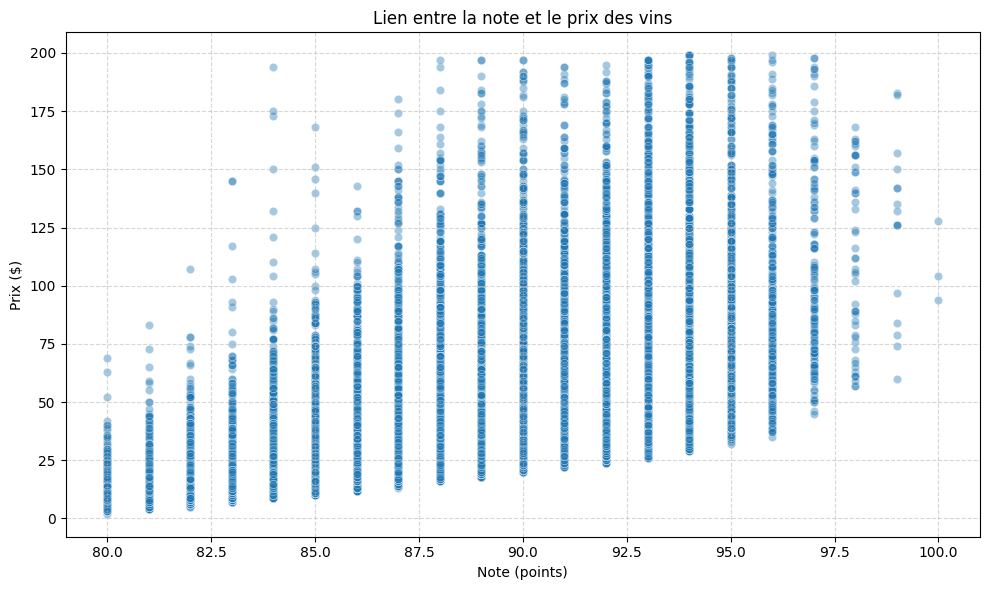

In [39]:
# Je définis la taille du graphique
plt.figure(figsize=(10, 6))

# Je crée un nuage de points : note en abscisse, prix en ordonnée afin mieux visualiser la relation entre les deux variables
sns.scatterplot(data=df_price, x="points", y="price", alpha=0.4)

# J'ajoute un titre et les axes
plt.title("Lien entre la note et le prix des vins")
plt.xlabel("Note (points)")
plt.ylabel("Prix ($)")

# Je rajoute aussi une grille pour la lisibilité
plt.grid(True, linestyle='--', alpha=0.5)

# Le graphique
plt.tight_layout()
plt.show()


**Mon analyse de ce graphique :**

*On peut observer une tendance générale : plus le prix d'un vin est élevé, plus sa note est élevée.
Cependant, il y a des exceptions, notamment pour les vins à bas prix qui peuvent avoir une note élevée, et vice versa.  
Cela montre que le prix n'est pas toujours un indicateur fiable de la qualité d'un vin.*

*En effet, beaucoup de vins très bien notés (90–94) restent autour de 20 à 50$.
Quelques valuers extrêmes apparaissent pour des vins notés 95 qui dépassent 200$.*

*Cela signifie que certains vins de qualité supérieure sont accessibles à un prix raisonnable, tandis que d'autres peuvent être très chers sans justification évidente de leur qualité.*

In [40]:
# Je poursuis avec la création d'un DataFrame df_price_clean pour l'intégration dans PowerBI
df_clean.to_csv("wine_clean.csv", index=False)

***L'analyse se poursuivra avec le fichier PowerBi, ainsi que le fichier PowerPoint qui contiendra la présentation de l'analyse du marché, ainsi que la proposition de prix pour le client.***